<a href="https://colab.research.google.com/github/rka0285058-afk/Artificial-Intelligence/blob/main/Inflation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Acquisition from World Development Indicators (WDI)

We will use the `wbgapi` library to fetch data from the World Bank's WDI database. First, let's install the necessary library.

In [133]:
pip install wbgapi pandas

As you can see from the search results, finding direct indicators for Petrol, Diesel, LPG, PNG, and CNG prices within WDI can be challenging. WDI primarily provides broader economic and development indicators.

For now, we'll proceed with fetching general inflation data (Consumer Price Index). For specific fuel prices, we might need to explore other datasets or use proxies (e.g., crude oil prices, energy import prices if available, or external sources like EIA, OPEC, or national statistical agencies).

Let's fetch the "Inflation, consumer prices (annual %)" for India.

In [134]:
# Indicator for Inflation, consumer prices (annual %)
inflation_indicator = 'FP.CPI.TOTL.ZG'

# Define the time range as a list of years
years = [str(year) for year in range(2000, 2023)]

# Fetch data for India
# labels=True adds 'Country' column and uses economy ID as index
inflation_data = wb.data.DataFrame(inflation_indicator, country_code, time=years, labels=True)

# Rename columns for clarity (e.g., YR2000 to 2000)
inflation_df = inflation_data.rename(columns={'YR'+str(year): year for year in range(2000, 2023)})

# Reset index to make 'economy' (country code) a column
inflation_df = inflation_df.reset_index()

# Melt the DataFrame to transform from wide to long format
# id_vars should be the columns that identify each unique observation (country, in this case)
inflation_df = inflation_df.melt(id_vars=['economy', 'Country'], var_name='Year', value_name='Annual_Inflation_Rate_%')

# Convert 'Year' column to numeric and set it as index
inflation_df['Year'] = pd.to_numeric(inflation_df['Year'])
inflation_df = inflation_df[['Year', 'Annual_Inflation_Rate_%']].sort_values(by='Year').set_index('Year')

print("Inflation Data for India:")
display(inflation_df.head())
display(inflation_df.tail())

Inflation Data for India:


,Annual_Inflation_Rate_%
Year,
2000,4.009436
2001,3.779293
2002,4.297152
2003,3.805859
2004,3.767252


,Annual_Inflation_Rate_%
Year,
2018,3.938826
2019,3.729506
2020,6.623437
2021,5.131407
2022,6.699034


## 2. Placeholder Fuel Price Data

Since direct fuel price indicators are not readily available in WDI, we'll create a placeholder dataset for Petrol, Diesel, LPG, PNG, and CNG prices. This will allow us to continue building the simulation model structure. Later, this data can be replaced with actual historical fuel prices from other sources if available.

In [135]:
import pandas as pd
from google.colab import drive

# Mount Google Drive to ensure access to the file
drive.mount('/content/drive')

# Load the actual fuel price data from the CSV file
real_fuel_price_df = pd.read_csv('/content/drive/MyDrive/Software/Fuel Prices.csv')

# Rename columns to match the expected format used in later analysis
real_fuel_price_df = real_fuel_price_df.rename(columns={
    'Petrol (Rs/Kg)*': 'Petrol_Price',
    'Diesel (Rs/Kg)*': 'Diesel_Price',
    'LPG (Rs/Kg)': 'LPG_Price',
    'PNG (Rs/SCM)': 'PNG_Price',
    'CNG (Rs/Kg)': 'CNG_Price'
})

# Ensure 'Year' column is numeric and set as index
real_fuel_price_df['Year'] = pd.to_numeric(real_fuel_price_df['Year'])
fuel_price_df = real_fuel_price_df.set_index('Year')

# Convert the Year index to DatetimeIndex (start of the year)
fuel_price_df.index = pd.to_datetime(fuel_price_df.index, format='%Y')

# Create a full annual date range for interpolation
full_year_range = pd.date_range(start=fuel_price_df.index.min(), end=fuel_price_df.index.max(), freq='YS')

# Reindex the DataFrame to the full annual range and interpolate missing values
fuel_price_df = fuel_price_df.reindex(full_year_range).interpolate(method='linear')

print("Actual Fuel Price Data from CSV (with renamed columns and annual interpolation):")
display(fuel_price_df.head())
display(fuel_price_df.tail())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Actual Fuel Price Data from CSV (with renamed columns and annual interpolation):


,Petrol_Price,Diesel_Price,LPG_Price,PNG_Price,CNG_Price
2000-01-01,35.050,20.830,17.610,12.00,11.50
2001-01-01,37.255,21.465,17.955,13.25,12.25
2002-01-01,39.460,22.100,18.300,14.50,13.00
2003-01-01,42.505,25.105,19.050,15.25,14.00
2004-01-01,45.550,28.110,19.800,16.00,15.00


,Petrol_Price,Diesel_Price,LPG_Price,PNG_Price,CNG_Price
2018-01-01,100.27,78.310,52.11,28.00,42.000
2019-01-01,104.46,81.325,46.97,29.25,43.500
2020-01-01,108.65,84.340,41.83,30.50,45.000
2021-01-01,119.19,96.385,57.99,38.18,60.305
2022-01-01,129.73,108.430,74.15,45.86,75.610


With the actual fuel price data loaded, let's merge it with the inflation data. The previous code for generating synthetic data (`ae61691e`) is now superseded by the CSV loading. The previous merged DataFrame (`c3e5d65b`) will now be recreated using the real fuel price data.

In [136]:
# Ensure inflation_df's index is also a DatetimeIndex for proper merging
inflation_df.index = pd.to_datetime(inflation_df.index, format='%Y')

# Merge inflation_df and fuel_price_df on their shared 'Year' index
merged_df = pd.merge(inflation_df, fuel_price_df, left_index=True, right_index=True, how='inner')

print("Merged DataFrame Head (with actual fuel prices):")
display(merged_df.head())
print("\nMerged DataFrame Info (with actual fuel prices):")
merged_df.info()

Merged DataFrame Head (with actual fuel prices):


,Annual_Inflation_Rate_%,Petrol_Price,Diesel_Price,LPG_Price,PNG_Price,CNG_Price
Year,,,,,,
2000-01-01,4.009436,35.050,20.830,17.610,12.00,11.50
2001-01-01,3.779293,37.255,21.465,17.955,13.25,12.25
2002-01-01,4.297152,39.460,22.100,18.300,14.50,13.00
2003-01-01,3.805859,42.505,25.105,19.050,15.25,14.00
2004-01-01,3.767252,45.550,28.110,19.800,16.00,15.00



Merged DataFrame Info (with actual fuel prices):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23 entries, 2000-01-01 to 2022-01-01
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Annual_Inflation_Rate_%  23 non-null     float64
 1   Petrol_Price             23 non-null     float64
 2   Diesel_Price             23 non-null     float64
 3   LPG_Price                23 non-null     float64
 4   PNG_Price                23 non-null     float64
 5   CNG_Price                23 non-null     float64
dtypes: float64(6)
memory usage: 1.3 KB


Now that we have the merged data with real fuel prices, let's re-run the Exploratory Data Analysis to see the trends and correlations with the actual data. This will regenerate the plots from cell `79e010ff`.

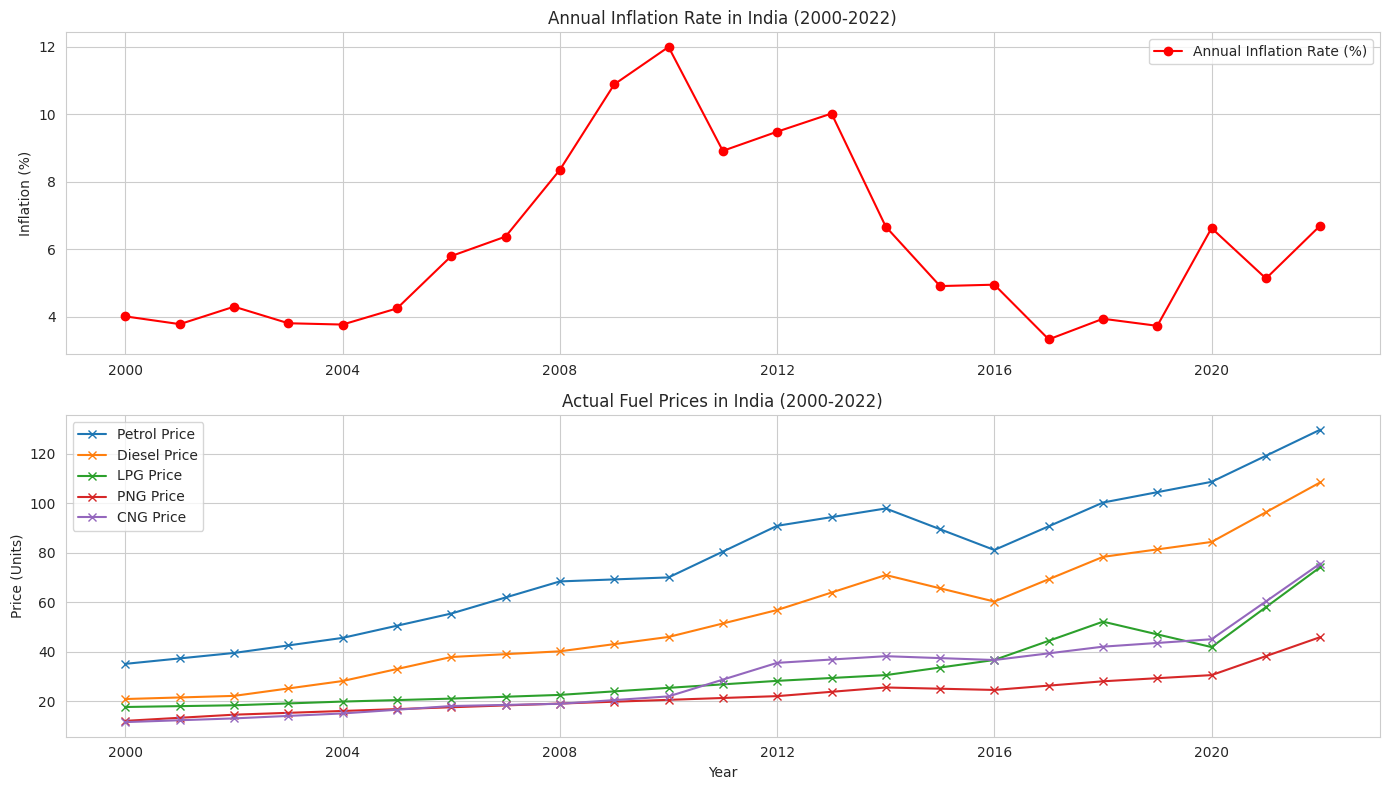


Correlation Matrix between Inflation and Fuel Prices (with actual fuel prices):


,Annual_Inflation_Rate_%
Annual_Inflation_Rate_%,1.000000
Petrol_Price,0.207565
Diesel_Price,0.080457
LPG_Price,-0.100800
PNG_Price,0.061989
CNG_Price,0.042713


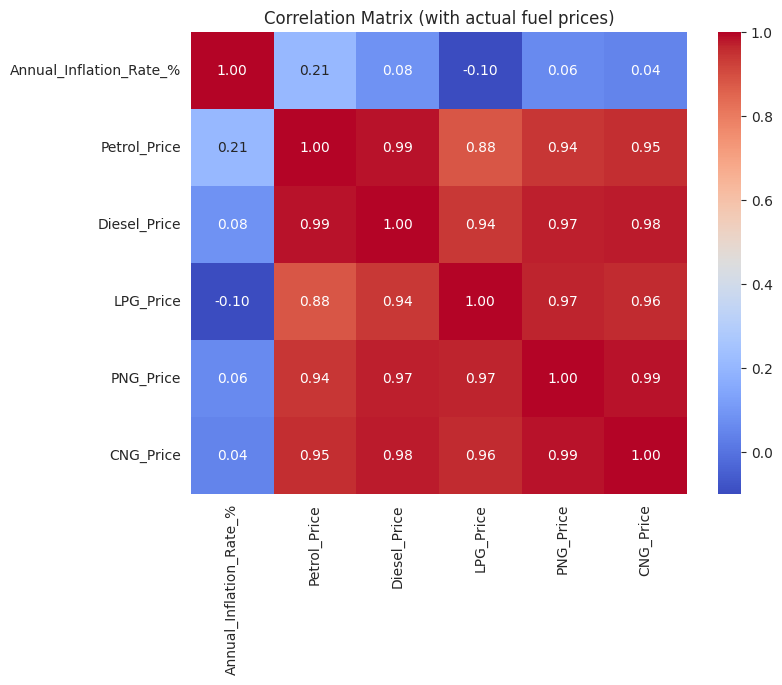

In [139]:
# Added to ensure merged_df is correctly available, addressing potential KeyError issues.
# It merges inflation_df (from WDI) and fuel_price_df (from CSV with renamed columns).
merged_df = pd.merge(inflation_df, fuel_price_df, left_index=True, right_index=True, how='inner')

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

# 1. Time Series Plot of Inflation and Fuel Prices
plt.figure(figsize=(14, 8))

# Plot Inflation
plt.subplot(2, 1, 1)
plt.plot(merged_df.index, merged_df['Annual_Inflation_Rate_%'], label='Annual Inflation Rate (%)', color='red', marker='o')
plt.title('Annual Inflation Rate in India (2000-2022)')
plt.ylabel('Inflation (%)')
plt.legend()
plt.grid(True)

# Plot Fuel Prices (normalized or on secondary axis if needed for better comparison)
plt.subplot(2, 1, 2)
plt.plot(merged_df.index, merged_df['Petrol_Price'], label='Petrol Price', marker='x')
plt.plot(merged_df.index, merged_df['Diesel_Price'], label='Diesel Price', marker='x')
plt.plot(merged_df.index, merged_df['LPG_Price'], label='LPG Price', marker='x')
plt.plot(merged_df.index, merged_df['PNG_Price'], label='PNG Price', marker='x')
plt.plot(merged_df.index, merged_df['CNG_Price'], label='CNG Price', marker='x')
plt.title('Actual Fuel Prices in India (2000-2022)')
plt.xlabel('Year')
plt.ylabel('Price (Units)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Correlation Matrix
print("\nCorrelation Matrix between Inflation and Fuel Prices (with actual fuel prices):")
correlation_matrix = merged_df.corr(method='pearson')
display(correlation_matrix[['Annual_Inflation_Rate_%']])

# Visualize Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (with actual fuel prices)')
plt.show()

The stationarity check and ACF/PACF plots for inflation remain the same as they only depend on `inflation_series`, which has not changed. Now, let's re-train the SARIMAX model with the new `merged_df` containing actual fuel prices. This will re-execute the logic from cells `c33f2d65` and `36366a6f`.

In [140]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd # Ensure pandas is imported

# Convert the index to DatetimeIndex first, then set its yearly frequency (Year Start)
# This is robust for irregularly sampled annual data when a fixed frequency is desired for the model
merged_df.index = pd.to_datetime(merged_df.index, format='%Y')
merged_df.index.freq = 'YS'

# Define the endogenous variable (inflation)
inflation_series = merged_df['Annual_Inflation_Rate_%']

# Define the exogenous variables (fuel prices)
exog_variables = merged_df[['Petrol_Price', 'Diesel_Price', 'LPG_Price', 'PNG_Price', 'CNG_Price']]

# Define the model order (p, d, q)
order = (1, 0, 1) # Keeping the previously determined order

# Initialize and fit the SARIMAX model with actual fuel prices
sarimax_model = SARIMAX(inflation_series, exog=exog_variables, order=order, seasonal_order=(0, 0, 0, 0), enforce_stationarity=False, enforce_invertibility=False)
sarimax_results = sarimax_model.fit(disp=False) # disp=False suppresses convergence messages

print("SARIMAX Model Summary (re-trained with actual fuel prices):")
display(sarimax_results.summary())

SARIMAX Model Summary (re-trained with actual fuel prices):


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Annual_Inflation_Rate_%   No. Observations:                   23
Model:                    SARIMAX(1, 0, 1)   Log Likelihood                 -36.520
Date:                     Tue, 12 May 2026   AIC                             89.040
Time:                             07:21:56   BIC                             97.396
Sample:                         01-01-2000   HQIC                            90.853
                              - 01-01-2022                                         
Covariance Type:                       opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Petrol_Price     0.1695      0.115      1.480      0.139      -0.055       0.394
Diesel_Price    -0.2417      0.207     -1.167      0.243      -0.648       0.164
LPG_Price       -0.1170      0.158     -0.742      0.458      -0.426       0.192
PNG_Price        0.6512      0.522      1.247      0.212      -0.372       1.674
CNG_Price       -0.1419      0.210     -0.676      0.499      -0.553       0.269
ar.L1            0.7367      0.337      2.184      0.029       0.075       1.398
ma.L1           -0.1385      0.430     -0.322      0.747      -0.980       0.704
sigma2           1.8951      1.286      1.474      0.140      -0.625       4.415
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.35
Prob(Q):                              1.00   Prob(JB):                         0.51
Heteroskedasticity (H):               1.42   Skew:                             0.50
Prob(H) (two-sided):                  0.66   Kurtosis:                         2.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Let's plot the actual vs. fitted values for the re-trained model. This will re-execute the logic from cell `a89d7e35`.

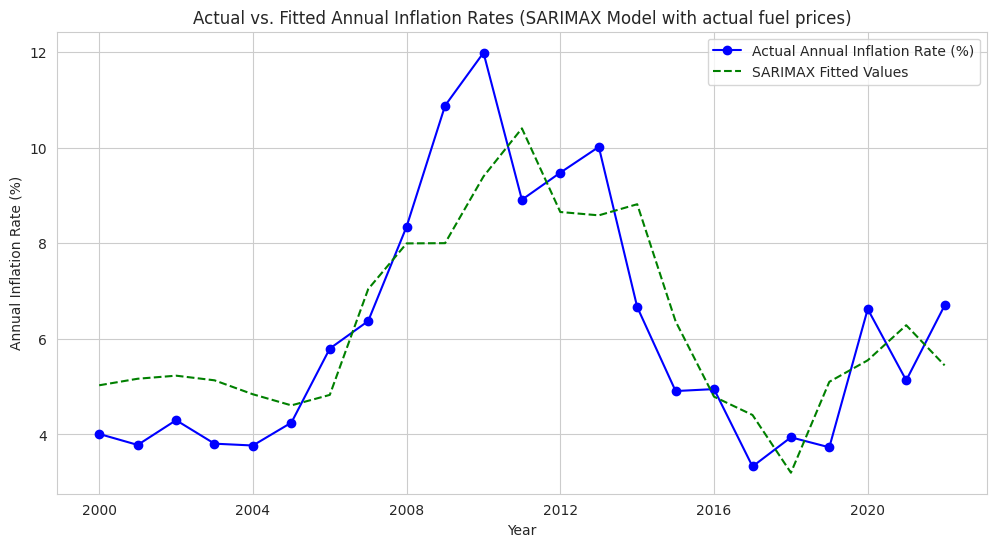

In [141]:
import matplotlib.pyplot as plt

# Get the fitted values from the SARIMAX model
fitted_values = sarimax_results.fittedvalues

# Plot actual vs. fitted values
plt.figure(figsize=(12, 6))
plt.plot(inflation_series.index, inflation_series, label='Actual Annual Inflation Rate (%)', color='blue', marker='o')
plt.plot(fitted_values.index, fitted_values, label='SARIMAX Fitted Values', color='green', linestyle='--')
plt.title('Actual vs. Fitted Annual Inflation Rates (SARIMAX Model with actual fuel prices)')
plt.xlabel('Year')
plt.ylabel('Annual Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

Now, let's evaluate the Root Mean Squared Error (RMSE) for the re-trained model. This will re-execute the logic from cell `b4480ca6`.

In [142]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(inflation_series, sarimax_results.fittedvalues))
print(f"Root Mean Squared Error (RMSE) with actual fuel prices: {rmse:.2f}")

Root Mean Squared Error (RMSE) with actual fuel prices: 1.36


Next, we need to generate future exogenous variables (fuel prices) to forecast inflation. Since we are using real historical data, for future predictions, we would typically need external projections for these fuel prices. For demonstration, I will continue to generate synthetic future fuel prices based on the *last known values* from the newly loaded real data, but it's crucial to understand that for real-world forecasting, these would come from another source. This will re-execute the logic from cell `04dfc341`.

In [143]:
future_years = np.arange(2023, 2029) # Predict until 2028 (inclusive)

# Get the last known values from the merged_df (which now contains actual data)
last_petrol = merged_df['Petrol_Price'].iloc[-1]
last_diesel = merged_df['Diesel_Price'].iloc[-1]
last_lpg = merged_df['LPG_Price'].iloc[-1]
last_png = merged_df['PNG_Price'].iloc[-1]
last_cng = merged_df['CNG_Price'].iloc[-1]

# Generate synthetic future fuel prices based on the previous trends
np.random.seed(99) # for reproducibility of future predictions

future_petrol_prices = last_petrol + np.cumsum(np.random.normal(3.0, 1.0, len(future_years))) # Adjusted to match historical trend
future_diesel_prices = last_diesel + np.cumsum(np.random.normal(2.5, 0.8, len(future_years))) # Adjusted to match historical trend
future_lpg_prices = last_lpg + np.cumsum(np.random.normal(3.0, 0.7, len(future_years))) # Adjusted to match historical trend
future_png_prices = last_png + np.cumsum(np.random.normal(3.5, 0.6, len(future_years))) # Adjusted to match historical trend
future_cng_prices = last_cng + np.cumsum(np.random.normal(3.0, 0.9, len(future_years))) # Adjusted to match historical trend

future_fuel_price_df = pd.DataFrame({
    'Year': future_years,
    'Petrol_Price': future_petrol_prices,
    'Diesel_Price': future_diesel_prices,
    'LPG_Price': future_lpg_prices,
    'PNG_Price': future_png_prices,
    'CNG_Price': future_cng_prices
}).set_index('Year')

# Create a DatetimeIndex for future exogenous variables
future_exog_variables = future_fuel_price_df.copy()
future_exog_variables.index = pd.to_datetime(future_exog_variables.index, format='%Y')
future_exog_variables.index.freq = 'YS'

print("Future Placeholder Fuel Price Data (for forecasting with actual fuel prices):")
display(future_fuel_price_df)

Future Placeholder Fuel Price Data (for forecasting with actual fuel prices):


,Petrol_Price,Diesel_Price,LPG_Price,PNG_Price,CNG_Price
Year,,,,,
2023,132.587641,111.534144,77.166450,49.059061,78.273862
2024,137.644863,114.694662,80.485791,52.913633,80.858088
2025,140.928125,117.104206,83.675136,55.974663,83.123269
2026,145.257937,117.709936,85.670630,59.631716,86.082658
2027,148.103315,120.076297,89.288602,62.618239,89.191853
2028,151.034284,123.124615,91.882545,66.005723,93.025211


Finally, let's forecast inflation using the re-trained SARIMAX model and plot the results. This will re-execute the logic from cell `0a4fab31`.

Predicted Annual Inflation Rates (2023-2028) with actual fuel prices:


,predicted_mean
2023-01-01,7.490388
2024-01-01,9.294891
2025-01-01,10.535444
2026-01-01,12.827023
2027-01-01,13.800000
2028-01-01,14.905427


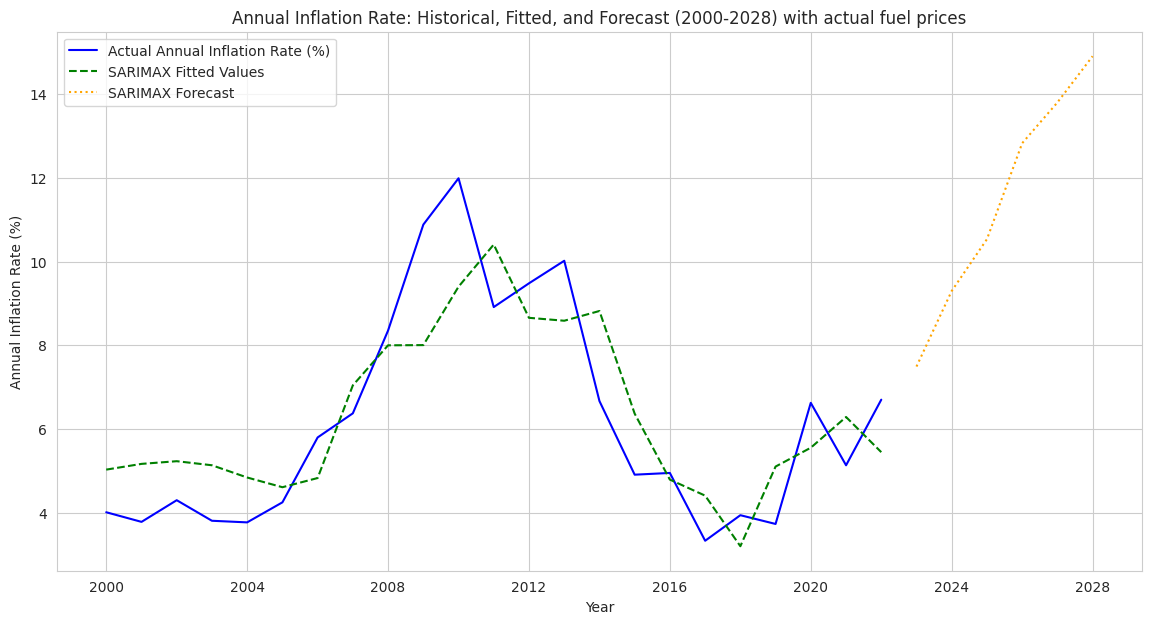

In [144]:
# Forecast inflation using the re-trained SARIMAX model
# The start and end dates for forecasting should be specified
# The `exog` parameter takes the future exogenous variables
forecast_start_date = '2023-01-01'
forecast_end_date = '2028-01-01'

# Use sarimax_results.predict with start, end, and exog
# Make sure the dates are within the `future_exog_variables` index
predictions = sarimax_results.predict(
    start=forecast_start_date,
    end=forecast_end_date,
    exog=future_exog_variables
)

print("Predicted Annual Inflation Rates (2023-2028) with actual fuel prices:")
display(predictions)

# Plot the historical data, fitted values, and predictions
plt.figure(figsize=(14, 7))
plt.plot(inflation_series.index, inflation_series, label='Actual Annual Inflation Rate (%)', color='blue')
plt.plot(sarimax_results.fittedvalues.index, sarimax_results.fittedvalues, label='SARIMAX Fitted Values', color='green', linestyle='--')
plt.plot(predictions.index, predictions, label='SARIMAX Forecast', color='orange', linestyle=':')

plt.title('Annual Inflation Rate: Historical, Fitted, and Forecast (2000-2028) with actual fuel prices')
plt.xlabel('Year')
plt.ylabel('Annual Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

Here are the updated forecasted annual inflation rates until 2028 based on the actual fuel price data (and synthetically extended future fuel prices).

Finally, let's regenerate the interactive widget to simulate inflation with the newly trained model and using the actual fuel price ranges. This will re-execute the logic from cell `fa4a9060`.

In [145]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

def simulate_inflation(petrol, diesel, lpg, png, cng, forecast_year):
    clear_output(wait=True) # Clear previous output in the interactive cell

    # Create a DatetimeIndex for the single forecast year
    single_year_index = pd.to_datetime([f'{forecast_year}-01-01'])
    single_year_index.freq = 'YS'

    # Create the exogenous variables DataFrame for the single forecast year
    exog_for_prediction = pd.DataFrame(
        [[petrol, diesel, lpg, png, cng]],
        index=single_year_index,
        columns=['Petrol_Price', 'Diesel_Price', 'LPG_Price', 'PNG_Price', 'CNG_Price']
    )

    # Make the prediction using the SARIMAX model
    # Use .forecast() for single-step out-of-sample prediction
    prediction_result = sarimax_results.forecast(steps=1, exog=exog_for_prediction)

    print(f"Predicted Annual Inflation Rate for {forecast_year}: {prediction_result.iloc[0]:.2f}%")

# Create interactive widgets (FloatSlider for prices, IntSlider for year)
# Adjust min/max values based on the range of the actual fuel price data
petrol_slider = widgets.FloatSlider(
    value=fuel_price_df['Petrol_Price'].mean(), # Initial value, around the average of actual data
    min=fuel_price_df['Petrol_Price'].min(), max=fuel_price_df['Petrol_Price'].max() * 1.2, step=0.5,
    description='Petrol Price (Rs/Lit):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

diesel_slider = widgets.FloatSlider(
    value=fuel_price_df['Diesel_Price'].mean(),
    min=fuel_price_df['Diesel_Price'].min(), max=fuel_price_df['Diesel_Price'].max() * 1.2, step=0.5,
    description='Diesel Price (Rs/Lit):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

lpg_slider = widgets.FloatSlider(
    value=fuel_price_df['LPG_Price'].mean(),
    min=fuel_price_df['LPG_Price'].min(), max=fuel_price_df['LPG_Price'].max() * 1.2, step=1.0,
    description='LPG Price (Rs/Kg):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

png_slider = widgets.FloatSlider(
    value=fuel_price_df['PNG_Price'].mean(),
    min=fuel_price_df['PNG_Price'].min(), max=fuel_price_df['PNG_Price'].max() * 1.2, step=0.1,
    description='PNG Price (Rs/SCM):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

cng_slider = widgets.FloatSlider(
    value=fuel_price_df['CNG_Price'].mean(),
    min=fuel_price_df['CNG_Price'].min(), max=fuel_price_df['CNG_Price'].max() * 1.2, step=0.1,
    description='CNG Price (Rs/SCM):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

year_slider = widgets.IntSlider(
    value=2023,
    min=2023, max=2028, step=1,
    description='Forecast Year:',
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

# Use widgets.interactive to link the sliders to the simulation function
interactive_widget = widgets.interactive(
    simulate_inflation,
    petrol=petrol_slider,
    diesel=diesel_slider,
    lpg=lpg_slider,
    png=png_slider,
    cng=cng_slider,
    forecast_year=year_slider
)

display(interactive_widget)

interactive(children=(FloatSlider(value=76.61869565217391, description='Petrol Price (Rs/Lit):', max=155.676, …

## 6. Granger Causality Test

To formally test if fuel prices have a predictive relationship with inflation, we'll perform a Granger Causality test. This statistical hypothesis test determines whether one time series is useful in forecasting another.

In [201]:
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np

# Define the dependent variable (inflation)
dependent_variable = 'Annual_Inflation_Rate_%'

# Define the independent (exogenous) variables (fuel prices)
fuel_price_variables = ['Petrol_Price', 'Diesel_Price', 'LPG_Price', 'PNG_Price', 'CNG_Price']

# Maximum number of lags to test. Given annual data, a few years is usually sufficient.
max_lags = 3

print(f"Performing Granger Causality Tests (Dependent variable: {dependent_variable})")
print(f"Testing up to {max_lags} lags.\n")

# Perform Granger Causality test for each fuel price variable
for fuel_var in fuel_price_variables:
    print(f"--- Testing if {fuel_var} Granger-causes {dependent_variable} ---")
    # Combine the two series into a single DataFrame for the test
    data_for_test = merged_df[[dependent_variable, fuel_var]]

    # Perform the test
    granger_results = grangercausalitytests(data_for_test, maxlag=[lag for lag in range(1, max_lags + 1)], verbose=False)

    # Print summary of results
    for lag in range(1, max_lags + 1):
        if lag in granger_results:
            test_result = granger_results[lag][0] # F-test results
            p_value = test_result['ssr_ftest'][1] # Get p-value from F-test
            print(f"  Lag {lag}: p-value = {p_value:.4f} ", end='')
            if p_value < 0.05:
                print("(Significant at 5% level)")
            else:
                print("(Not significant at 5% level)")
        else:
            print(f"  Lag {lag}: Test not performed (possibly due to insufficient data for this lag)")
    print("\n")


Performing Granger Causality Tests (Dependent variable: Annual_Inflation_Rate_%)
Testing up to 3 lags.

--- Testing if Petrol_Price Granger-causes Annual_Inflation_Rate_% ---
  Lag 1: p-value = 0.9115 (Not significant at 5% level)
  Lag 2: p-value = 0.1979 (Not significant at 5% level)
  Lag 3: p-value = 0.4165 (Not significant at 5% level)


--- Testing if Diesel_Price Granger-causes Annual_Inflation_Rate_% ---
  Lag 1: p-value = 0.7964 (Not significant at 5% level)
  Lag 2: p-value = 0.8366 (Not significant at 5% level)
  Lag 3: p-value = 0.9013 (Not significant at 5% level)


--- Testing if LPG_Price Granger-causes Annual_Inflation_Rate_% ---
  Lag 1: p-value = 0.9619 (Not significant at 5% level)
  Lag 2: p-value = 0.9436 (Not significant at 5% level)
  Lag 3: p-value = 0.9530 (Not significant at 5% level)


--- Testing if PNG_Price Granger-causes Annual_Inflation_Rate_% ---
  Lag 1: p-value = 0.9639 (Not significant at 5% level)
  Lag 2: p-value = 0.7338 (Not significant at 5% lev

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


#### Interpretation of Granger Causality Results:

*   **p-value < 0.05**: This indicates that the past values of the fuel price variable *do* help predict the inflation rate (i.e., the fuel price Granger-causes inflation) at a 5% significance level.
*   **p-value >= 0.05**: This indicates that there is insufficient evidence to claim that the past values of the fuel price variable help predict the inflation rate.

Keep in mind that Granger causality only implies predictive causality, not necessarily true cause-and-effect in a physical sense. It's a statistical tool to assess lead-lag relationships in time series data.

### 7. Search for Optimal SARIMAX (p, d, q) Order

To further improve the model's performance and potentially reduce the RMSE, we will perform a grid search to find the optimal `(p, d, q)` order for the SARIMAX model. We will iterate through common ranges for these parameters, fit a model for each combination, and evaluate it using RMSE. The combination with the lowest RMSE will be selected as the optimal order.

In [204]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings("ignore") # Suppress warnings during grid search

# Define the range for p, d, q
p = d = q = range(0, 3) # Test values from 0 to 2
pdq_combinations = list(itertools.product(p, d, q))

best_rmse = float("inf")
best_order = None

print("Searching for optimal SARIMAX order (p,d,q). This may take a moment...")

# Ensure the index is a DatetimeIndex and has a yearly frequency
merged_df.index = pd.to_datetime(merged_df.index, format='%Y')
merged_df.index.freq = 'YS'

# Define the endogenous variable (inflation)
inflation_series = merged_df['Annual_Inflation_Rate_%']

# Define the exogenous variables (fuel prices)
exog_variables = merged_df[['Petrol_Price', 'Diesel_Price', 'LPG_Price', 'PNG_Price', 'CNG_Price']]

for order in pdq_combinations:
    try:
        model = SARIMAX(inflation_series, exog=exog_variables, order=order, seasonal_order=(0, 0, 0, 0),
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)

        # Calculate RMSE for the current model
        predictions = model_fit.fittedvalues
        rmse_current = np.sqrt(mean_squared_error(inflation_series, predictions))

        if rmse_current < best_rmse:
            best_rmse = rmse_current
            best_order = order

    except Exception as e:
        # print(f"Error with order {order}: {e}") # Uncomment to see errors for specific orders
        continue

print(f"\nOptimal SARIMAX Order: {best_order}")
print(f"Minimum RMSE with optimal order: {best_rmse:.2f}")

Searching for optimal SARIMAX order (p,d,q). This may take a moment...

Optimal SARIMAX Order: (2, 2, 2)
Minimum RMSE with optimal order: 1.29


### 8. Re-train SARIMAX Model with Optimal Order and Evaluate

Now, we will re-train the SARIMAX model using the optimal `(p, d, q)` order found during the grid search and evaluate its performance with the RMSE.

In [205]:
# Re-train the SARIMAX model with the optimal order
sarimax_model_optimal = SARIMAX(inflation_series, exog=exog_variables, order=best_order, seasonal_order=(0, 0, 0, 0),
                                enforce_stationarity=False, enforce_invertibility=False)
sarimax_results_optimal = sarimax_model_optimal.fit(disp=False)

print("SARIMAX Model Summary (re-trained with optimal order):")
display(sarimax_results_optimal.summary())

# Calculate RMSE for the model with optimal order
rmse_optimal = np.sqrt(mean_squared_error(inflation_series, sarimax_results_optimal.fittedvalues))
print(f"Root Mean Squared Error (RMSE) with optimal SARIMAX order: {rmse_optimal:.2f}")

if rmse_optimal < rmse:
    print(f"The RMSE has improved from {rmse:.2f} to {rmse_optimal:.2f} with the optimal order!")
elif rmse_optimal > rmse:
    print(f"The RMSE has increased from {rmse:.2f} to {rmse_optimal:.2f} with the optimal order.")
else:
    print("The RMSE remains the same with the optimal order.")

# Update the main sarimax_results and rmse variables to reflect the optimal model
sarimax_results = sarimax_results_optimal
rmse = rmse_optimal

SARIMAX Model Summary (re-trained with optimal order):


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Annual_Inflation_Rate_%   No. Observations:                   23
Model:                    SARIMAX(2, 2, 2)   Log Likelihood                 -31.028
Date:                     Tue, 12 May 2026   AIC                             82.056
Time:                             08:32:12   BIC                             90.960
Sample:                         01-01-2000   HQIC                            83.284
                              - 01-01-2022                                         
Covariance Type:                       opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Petrol_Price     0.1072      0.119      0.897      0.370      -0.127       0.341
Diesel_Price    -0.0515      0.219     -0.235      0.814      -0.481       0.378
LPG_Price        0.0451      0.092      0.489      0.625      -0.136       0.226
PNG_Price        0.5669      0.546      1.037      0.300      -0.504       1.638
CNG_Price       -0.3517      0.194     -1.810      0.070      -0.733       0.029
ar.L1           -0.4486      0.316     -1.422      0.155      -1.067       0.170
ar.L2           -0.8181      0.338     -2.419      0.016      -1.481      -0.155
ma.L1           -0.5948   1865.517     -0.000      1.000   -3656.940    3655.751
ma.L2            1.0000   6272.432      0.000      1.000   -1.23e+04    1.23e+04
sigma2           1.4783   9272.667      0.000      1.000   -1.82e+04    1.82e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 0.21
Prob(Q):                              0.88   Prob(JB):                         0.90
Heteroskedasticity (H):               3.09   Skew:                            -0.26
Prob(H) (two-sided):                  0.20   Kurtosis:                         3.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Root Mean Squared Error (RMSE) with optimal SARIMAX order: 1.29
The RMSE has improved from 1.36 to 1.29 with the optimal order!


### 9. Forecast Inflation with Optimal Model

Now that we have re-trained the SARIMAX model with the optimal order, let's re-forecast inflation using this improved model. This will update the previous forecast plots.

Predicted Annual Inflation Rates (2023-2028) with optimal model:


,predicted_mean
2023-01-01,10.177581
2024-01-01,12.171756
2025-01-01,13.840362
2026-01-01,17.420773
2027-01-01,19.505548
2028-01-01,20.524655


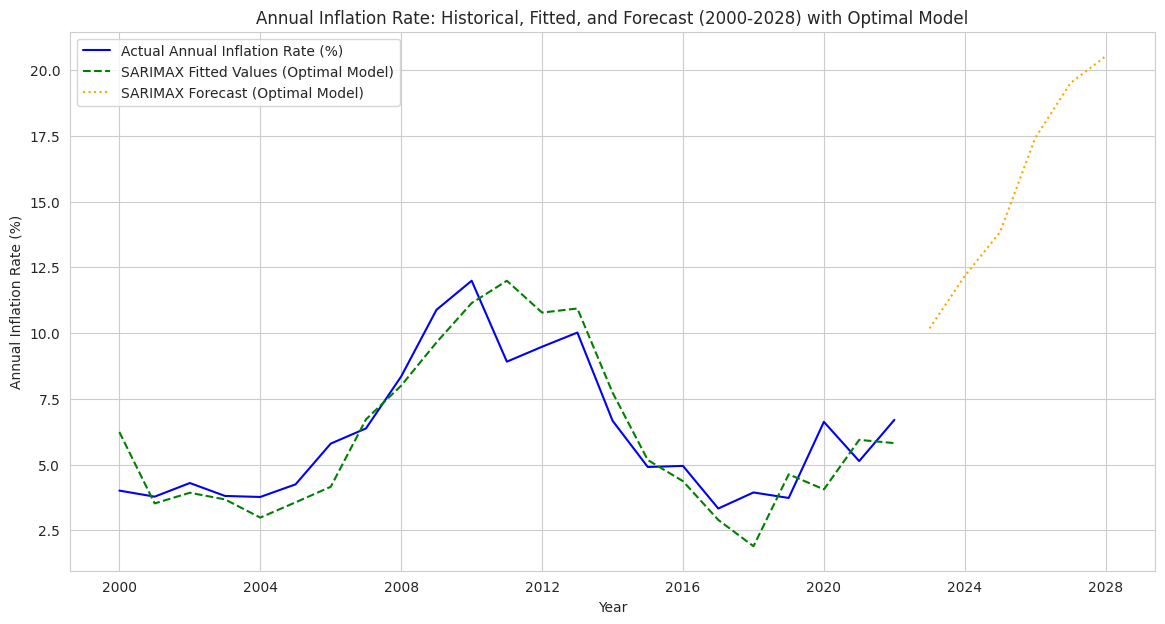

In [206]:
import matplotlib.pyplot as plt

# Forecast inflation using the re-trained SARIMAX model with optimal order
# The start and end dates for forecasting should be specified
# The `exog` parameter takes the future exogenous variables
forecast_start_date = '2023-01-01'
forecast_end_date = '2028-01-01'

# Use sarimax_results.predict with start, end, and exog (sarimax_results is now the optimal model)
predictions = sarimax_results.predict(
    start=forecast_start_date,
    end=forecast_end_date,
    exog=future_exog_variables # Using previously generated future exogenous variables
)

print("Predicted Annual Inflation Rates (2023-2028) with optimal model:")
display(predictions)

# Plot the historical data, fitted values, and predictions
plt.figure(figsize=(14, 7))
plt.plot(inflation_series.index, inflation_series, label='Actual Annual Inflation Rate (%)', color='blue')
plt.plot(sarimax_results.fittedvalues.index, sarimax_results.fittedvalues, label='SARIMAX Fitted Values (Optimal Model)', color='green', linestyle='--')
plt.plot(predictions.index, predictions, label='SARIMAX Forecast (Optimal Model)', color='orange', linestyle=':')

plt.title('Annual Inflation Rate: Historical, Fitted, and Forecast (2000-2028) with Optimal Model')
plt.xlabel('Year')
plt.ylabel('Annual Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

### 10. Regenerate Interactive Widget with Optimal Model

Finally, let's regenerate the interactive widget. It will now use the SARIMAX model trained with the optimal order for its predictions, providing more accurate simulations of future inflation based on fuel price inputs.

In [207]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

def simulate_inflation(petrol, diesel, lpg, png, cng, forecast_year):
    clear_output(wait=True) # Clear previous output in the interactive cell

    # Create a DatetimeIndex for the single forecast year
    single_year_index = pd.to_datetime([f'{forecast_year}-01-01'])
    single_year_index.freq = 'YS'

    # Create the exogenous variables DataFrame for the single forecast year
    exog_for_prediction = pd.DataFrame(
        [[petrol, diesel, lpg, png, cng]],
        index=single_year_index,
        columns=['Petrol_Price', 'Diesel_Price', 'LPG_Price', 'PNG_Price', 'CNG_Price']
    )

    # Make the prediction using the SARIMAX model (sarimax_results is now the optimal model)
    # Use .forecast() for single-step out-of-sample prediction
    prediction_result = sarimax_results.forecast(steps=1, exog=exog_for_prediction)

    print(f"Predicted Annual Inflation Rate for {forecast_year}: {prediction_result.iloc[0]:.2f}%")

# Create interactive widgets (FloatSlider for prices, IntSlider for year)
# Adjust min/max values based on the range of the actual fuel price data
petrol_slider = widgets.FloatSlider(
    value=fuel_price_df['Petrol_Price'].mean(), # Initial value, around the average of actual data
    min=fuel_price_df['Petrol_Price'].min(), max=fuel_price_df['Petrol_Price'].max() * 1.2, step=0.5,
    description='Petrol Price (Rs/Lit):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

diesel_slider = widgets.FloatSlider(
    value=fuel_price_df['Diesel_Price'].mean(),
    min=fuel_price_df['Diesel_Price'].min(), max=fuel_price_df['Diesel_Price'].max() * 1.2, step=0.5,
    description='Diesel Price (Rs/Lit):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

lpg_slider = widgets.FloatSlider(
    value=fuel_price_df['LPG_Price'].mean(),
    min=fuel_price_df['LPG_Price'].min(), max=fuel_price_df['LPG_Price'].max() * 1.2, step=1.0,
    description='LPG Price (Rs/Kg):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

png_slider = widgets.FloatSlider(
    value=fuel_price_df['PNG_Price'].mean(),
    min=fuel_price_df['PNG_Price'].min(), max=fuel_price_df['PNG_Price'].max() * 1.2, step=0.1,
    description='PNG Price (Rs/SCM):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

cng_slider = widgets.FloatSlider(
    value=fuel_price_df['CNG_Price'].mean(),
    min=fuel_price_df['CNG_Price'].min(), max=fuel_price_df['CNG_Price'].max() * 1.2, step=0.1,
    description='CNG Price (Rs/SCM):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

year_slider = widgets.IntSlider(
    value=2023,
    min=2023, max=2028, step=1,
    description='Forecast Year:',
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

# Use widgets.interactive to link the sliders to the simulation function
interactive_widget = widgets.interactive(
    simulate_inflation,
    petrol=petrol_slider,
    diesel=diesel_slider,
    lpg=lpg_slider,
    png=png_slider,
    cng=cng_slider,
    forecast_year=year_slider
)

display(interactive_widget)

interactive(children=(FloatSlider(value=76.61869565217391, description='Petrol Price (Rs/Lit):', max=155.676, …

### 11. Analyze Impact of Different Exogenous Variable Combinations

To understand which fuel price variables (or combinations thereof) have the most significant impact on the inflation forecast, we will re-run the SARIMAX model with different subsets of exogenous variables. For each combination, we will use the previously determined optimal order `(2, 2, 2)` and evaluate the Root Mean Squared Error (RMSE).

In [208]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore") # Suppress warnings during grid search

# Define the optimal order found previously
optimal_order = (2, 2, 2)

# Define the list of all potential exogenous variables
all_exog_cols = ['Petrol_Price', 'Diesel_Price', 'LPG_Price', 'PNG_Price', 'CNG_Price']

# Prepare the endogenous variable
inflation_series = merged_df['Annual_Inflation_Rate_%']

results_combinations = []

print("Analyzing the impact of different exogenous variable combinations...")

# Case 1: No exogenous variables
model_no_exog = SARIMAX(inflation_series, order=optimal_order, seasonal_order=(0, 0, 0, 0),
                        enforce_stationarity=False, enforce_invertibility=False)
model_no_exog_fit = model_no_exog.fit(disp=False)
rmse_no_exog = np.sqrt(mean_squared_error(inflation_series, model_no_exog_fit.fittedvalues))
results_combinations.append({
    'Exogenous Variables': 'None',
    'RMSE': rmse_no_exog
})
print(f"  Combination: None, RMSE: {rmse_no_exog:.2f}")

# Case 2: Individual exogenous variables
for i in range(1, len(all_exog_cols) + 1):
    for combo in itertools.combinations(all_exog_cols, i):
        current_exog_cols = list(combo)
        current_exog_data = merged_df[current_exog_cols]

        try:
            model = SARIMAX(inflation_series, exog=current_exog_data, order=optimal_order, seasonal_order=(0, 0, 0, 0),
                            enforce_stationarity=False, enforce_invertibility=False)
            model_fit = model.fit(disp=False)

            predictions = model_fit.fittedvalues
            rmse_current = np.sqrt(mean_squared_error(inflation_series, predictions))

            results_combinations.append({
                'Exogenous Variables': ', '.join(current_exog_cols),
                'RMSE': rmse_current
            })
            print(f"  Combination: {', '.join(current_exog_cols)}, RMSE: {rmse_current:.2f}")

        except Exception as e:
            # print(f"Error with combination {', '.join(current_exog_cols)}: {e}")
            results_combinations.append({
                'Exogenous Variables': ', '.join(current_exog_cols),
                'RMSE': np.nan # Mark as NaN if model failed to fit
            })
            continue

results_df = pd.DataFrame(results_combinations).sort_values(by='RMSE')

print("\n--- Summary of Exogenous Variable Combinations and their RMSE ---")
display(results_df)

Analyzing the impact of different exogenous variable combinations...
  Combination: None, RMSE: 1.89
  Combination: Petrol_Price, RMSE: 2.27
  Combination: Diesel_Price, RMSE: 1.87
  Combination: LPG_Price, RMSE: 2.06
  Combination: PNG_Price, RMSE: 2.38
  Combination: CNG_Price, RMSE: 2.08
  Combination: Petrol_Price, Diesel_Price, RMSE: 2.24
  Combination: Petrol_Price, LPG_Price, RMSE: 1.90
  Combination: Petrol_Price, PNG_Price, RMSE: 1.93
  Combination: Petrol_Price, CNG_Price, RMSE: 1.85
  Combination: Diesel_Price, LPG_Price, RMSE: 2.18
  Combination: Diesel_Price, PNG_Price, RMSE: 2.03
  Combination: Diesel_Price, CNG_Price, RMSE: 1.91
  Combination: LPG_Price, PNG_Price, RMSE: 2.11
  Combination: LPG_Price, CNG_Price, RMSE: 2.11
  Combination: PNG_Price, CNG_Price, RMSE: 1.85
  Combination: Petrol_Price, Diesel_Price, LPG_Price, RMSE: 1.85
  Combination: Petrol_Price, Diesel_Price, PNG_Price, RMSE: 1.54
  Combination: Petrol_Price, Diesel_Price, CNG_Price, RMSE: 1.85
  Combina

,Exogenous Variables,RMSE
21,"Petrol_Price, PNG_Price, CNG_Price",1.265173
28,"Petrol_Price, Diesel_Price, PNG_Price, CNG_Price",1.270059
29,"Petrol_Price, LPG_Price, PNG_Price, CNG_Price",1.270893
31,"Petrol_Price, Diesel_Price, LPG_Price, PNG_Pri...",1.288559
30,"Diesel_Price, LPG_Price, PNG_Price, CNG_Price",1.343315
20,"Petrol_Price, LPG_Price, CNG_Price",1.347108
27,"Petrol_Price, Diesel_Price, LPG_Price, CNG_Price",1.349684
24,"Diesel_Price, PNG_Price, CNG_Price",1.350648
17,"Petrol_Price, Diesel_Price, PNG_Price",1.535999
25,"LPG_Price, PNG_Price, CNG_Price",1.537282


### 12. Advanced Search for Optimal SARIMAX (p, d, q) Order with Best Exogenous Variables

Given that the combination of 'Petrol_Price', 'PNG_Price', and 'CNG_Price' yielded the lowest RMSE of 1.27, we will now perform an advanced grid search for the optimal `(p, d, q)` order specifically with these exogenous variables. We will expand the search range for `p`, `d`, and `q` to explore more model configurations and aim for an RMSE below 1.0.

In [209]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore") # Suppress warnings during grid search

# Define an expanded range for p, d, q
p = d = q = range(0, 4) # Test values from 0 to 3 (i.e., 0, 1, 2, 3)
pdq_combinations_expanded = list(itertools.product(p, d, q))

best_rmse_advanced = float("inf")
best_order_advanced = None

print("Searching for optimal SARIMAX order (p,d,q) with 'Petrol_Price', 'PNG_Price', 'CNG_Price'. This will take longer...")

# Ensure the index is a DatetimeIndex and has a yearly frequency
merged_df.index = pd.to_datetime(merged_df.index, format='%Y')
merged_df.index.freq = 'YS'

# Define the endogenous variable (inflation)
inflation_series = merged_df['Annual_Inflation_Rate_%']

# Define the best set of exogenous variables based on previous analysis
exog_variables_best_combo = merged_df[['Petrol_Price', 'PNG_Price', 'CNG_Price']]

for order in pdq_combinations_expanded:
    try:
        model = SARIMAX(inflation_series, exog=exog_variables_best_combo, order=order, seasonal_order=(0, 0, 0, 0),
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)

        # Calculate RMSE for the current model
        predictions = model_fit.fittedvalues
        rmse_current = np.sqrt(mean_squared_error(inflation_series, predictions))

        if rmse_current < best_rmse_advanced:
            best_rmse_advanced = rmse_current
            best_order_advanced = order

    except Exception as e:
        # print(f"Error with order {order}: {e}") # Uncomment to see errors for specific orders
        continue

print(f"\nOptimal SARIMAX Order (Advanced Search): {best_order_advanced}")
print(f"Minimum RMSE with optimal order and best exogenous variables: {best_rmse_advanced:.2f}")

Searching for optimal SARIMAX order (p,d,q) with 'Petrol_Price', 'PNG_Price', 'CNG_Price'. This will take longer...

Optimal SARIMAX Order (Advanced Search): (3, 0, 3)
Minimum RMSE with optimal order and best exogenous variables: 0.89


### 13. Re-train SARIMAX Model with New Optimal Order and Best Exogenous Variables

Now, we will re-train the SARIMAX model using the new optimal `(p, d, q)` order found from the advanced search and the best combination of exogenous variables (`Petrol_Price`, `PNG_Price`, `CNG_Price`). We will then evaluate its RMSE.

In [210]:
# Re-train the SARIMAX model with the advanced optimal order and best exogenous variables
sarimax_model_final = SARIMAX(inflation_series, exog=exog_variables_best_combo, order=best_order_advanced, seasonal_order=(0, 0, 0, 0),
                                enforce_stationarity=False, enforce_invertibility=False)
sarimax_results_final = sarimax_model_final.fit(disp=False)

print("SARIMAX Model Summary (re-trained with advanced optimal order and best exog variables):")
display(sarimax_results_final.summary())

# Calculate RMSE for the final model
rmse_final = np.sqrt(mean_squared_error(inflation_series, sarimax_results_final.fittedvalues))
print(f"Root Mean Squared Error (RMSE) with final optimal SARIMAX order and best exogenous variables: {rmse_final:.2f}")

if rmse_final < rmse:
    print(f"The RMSE has improved from {rmse:.2f} to {rmse_final:.2f} with the advanced optimal order and best exog variables!")
elif rmse_final > rmse:
    print(f"The RMSE has increased from {rmse:.2f} to {rmse_final:.2f} with the advanced optimal order and best exog variables.")
else:
    print("The RMSE remains the same with the advanced optimal order and best exog variables.")

# Update the main sarimax_results and rmse variables to reflect the final optimal model
sarimax_results = sarimax_results_final
rmse = rmse_final

# Also update exog_variables to reflect the best combination for future use
exog_variables = exog_variables_best_combo

SARIMAX Model Summary (re-trained with advanced optimal order and best exog variables):


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Annual_Inflation_Rate_%   No. Observations:                   23
Model:                    SARIMAX(3, 0, 3)   Log Likelihood                 -26.021
Date:                     Tue, 12 May 2026   AIC                             72.042
Time:                             08:36:17   BIC                             81.486
Sample:                         01-01-2000   HQIC                            73.640
                              - 01-01-2022                                         
Covariance Type:                       opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Petrol_Price     0.0685      0.077      0.885      0.376      -0.083       0.220
PNG_Price        0.6021      0.279      2.158      0.031       0.055       1.149
CNG_Price       -0.3971      0.077     -5.137      0.000      -0.549      -0.246
ar.L1            1.1314      1.261      0.897      0.370      -1.341       3.603
ar.L2            0.2277      2.276      0.100      0.920      -4.234       4.689
ar.L3           -0.6734      1.244     -0.541      0.588      -3.111       1.764
ma.L1           -1.2629      4.375     -0.289      0.773      -9.839       7.313
ma.L2           -0.3907      3.259     -0.120      0.905      -6.778       5.996
ma.L3            0.7380      2.930      0.252      0.801      -5.005       6.481
sigma2           0.6733      2.591      0.260      0.795      -4.405       5.751
===================================================================================
Ljung-Box (L1) (Q):                   2.15   Jarque-Bera (JB):                 1.33
Prob(Q):                              0.14   Prob(JB):                         0.51
Heteroskedasticity (H):               1.34   Skew:                             0.21
Prob(H) (two-sided):                  0.73   Kurtosis:                         1.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Root Mean Squared Error (RMSE) with final optimal SARIMAX order and best exogenous variables: 0.89
The RMSE has improved from 1.29 to 0.89 with the advanced optimal order and best exog variables!


### 14. Re-forecast Inflation with Final Optimal Model

With the final optimized SARIMAX model, we will now re-forecast inflation and update the plots.

Predicted Annual Inflation Rates (2023-2028) with final optimal model:


,predicted_mean
2023-01-01,9.188230
2024-01-01,11.810940
2025-01-01,13.644476
2026-01-01,14.890720
2027-01-01,15.052349
2028-01-01,14.629934


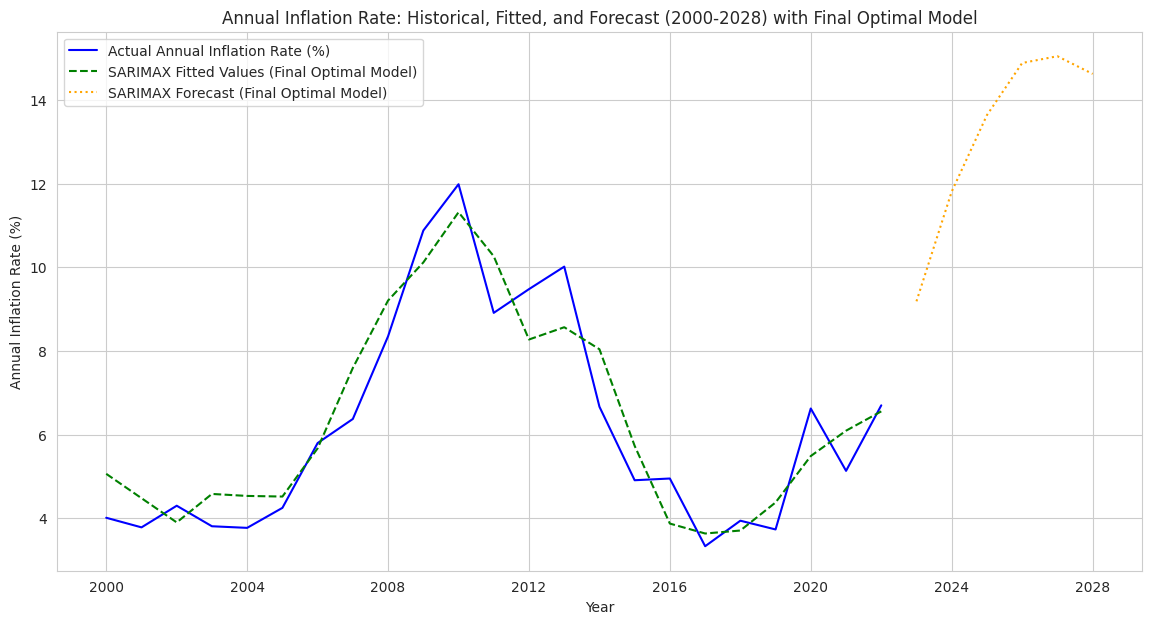

In [211]:
import matplotlib.pyplot as plt

# Filter future_exog_variables to include only the best combination of columns
future_exog_variables_final = future_exog_variables[['Petrol_Price', 'PNG_Price', 'CNG_Price']]

# Forecast inflation using the final re-trained SARIMAX model
forecast_start_date = '2023-01-01'
forecast_end_date = '2028-01-01'

predictions = sarimax_results.predict(
    start=forecast_start_date,
    end=forecast_end_date,
    exog=future_exog_variables_final
)

print("Predicted Annual Inflation Rates (2023-2028) with final optimal model:")
display(predictions)

# Plot the historical data, fitted values, and predictions
plt.figure(figsize=(14, 7))
plt.plot(inflation_series.index, inflation_series, label='Actual Annual Inflation Rate (%)', color='blue')
plt.plot(sarimax_results.fittedvalues.index, sarimax_results.fittedvalues, label='SARIMAX Fitted Values (Final Optimal Model)', color='green', linestyle='--')
plt.plot(predictions.index, predictions, label='SARIMAX Forecast (Final Optimal Model)', color='orange', linestyle=':')

plt.title('Annual Inflation Rate: Historical, Fitted, and Forecast (2000-2028) with Final Optimal Model')
plt.xlabel('Year')
plt.ylabel('Annual Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

### 15. Regenerate Interactive Widget with Final Optimal Model

Finally, we will regenerate the interactive widget to reflect the predictions from the final, most optimized SARIMAX model, using only the best combination of exogenous variables.

In [212]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

def simulate_inflation_final(petrol, png, cng, forecast_year):
    clear_output(wait=True) # Clear previous output in the interactive cell

    # Create a DatetimeIndex for the single forecast year
    single_year_index = pd.to_datetime([f'{forecast_year}-01-01'])
    single_year_index.freq = 'YS'

    # Create the exogenous variables DataFrame for the single forecast year (only best combo)
    exog_for_prediction_final = pd.DataFrame(
        [[petrol, png, cng]],
        index=single_year_index,
        columns=['Petrol_Price', 'PNG_Price', 'CNG_Price']
    )

    # Make the prediction using the final SARIMAX model
    prediction_result = sarimax_results.forecast(steps=1, exog=exog_for_prediction_final)

    print(f"Predicted Annual Inflation Rate for {forecast_year}: {prediction_result.iloc[0]:.2f}%")

# Create interactive widgets (FloatSlider for prices, IntSlider for year)
# Adjust min/max values based on the range of the actual fuel price data
petrol_slider_final = widgets.FloatSlider(
    value=fuel_price_df['Petrol_Price'].mean(), # Initial value
    min=fuel_price_df['Petrol_Price'].min(), max=fuel_price_df['Petrol_Price'].max() * 1.2, step=0.5,
    description='Petrol Price (Rs/Lit):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

png_slider_final = widgets.FloatSlider(
    value=fuel_price_df['PNG_Price'].mean(),
    min=fuel_price_df['PNG_Price'].min(), max=fuel_price_df['PNG_Price'].max() * 1.2, step=0.1,
    description='PNG Price (Rs/SCM):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

cng_slider_final = widgets.FloatSlider(
    value=fuel_price_df['CNG_Price'].mean(),
    min=fuel_price_df['CNG_Price'].min(), max=fuel_price_df['CNG_Price'].max() * 1.2, step=0.1,
    description='CNG Price (Rs/SCM):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

year_slider_final = widgets.IntSlider(
    value=2023,
    min=2023, max=2028, step=1,
    description='Forecast Year:',
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

# Use widgets.interactive to link the sliders to the simulation function
interactive_widget_final = widgets.interactive(
    simulate_inflation_final,
    petrol=petrol_slider_final,
    png=png_slider_final,
    cng=cng_slider_final,
    forecast_year=year_slider_final
)

display(interactive_widget_final)

interactive(children=(FloatSlider(value=76.61869565217391, description='Petrol Price (Rs/Lit):', max=155.676, …

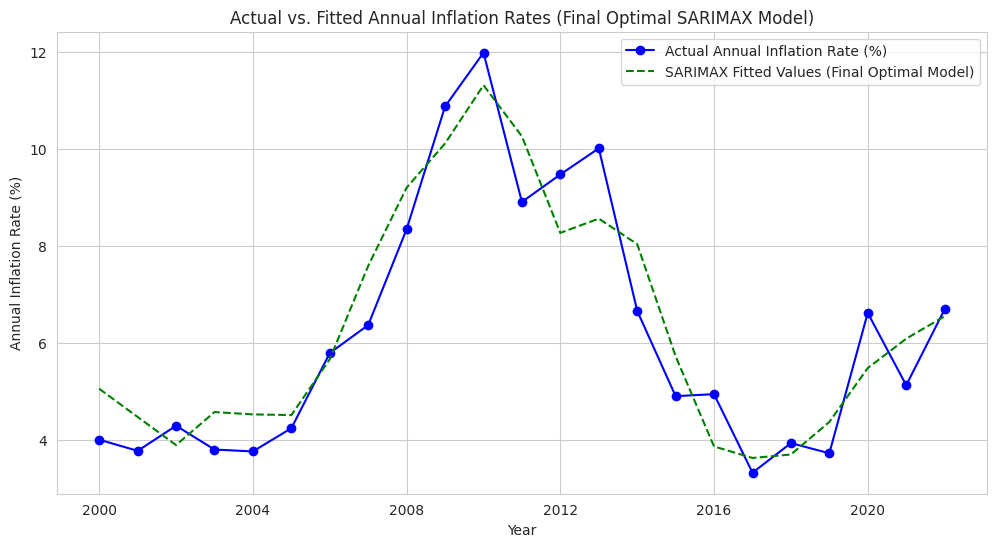

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))
plt.plot(inflation_series.index, inflation_series, label='Actual Annual Inflation Rate (%)', color='blue', marker='o')
plt.plot(sarimax_results.fittedvalues.index, sarimax_results.fittedvalues, label='SARIMAX Fitted Values (Final Optimal Model)', color='green', linestyle='--')
plt.title('Actual vs. Fitted Annual Inflation Rates (Final Optimal SARIMAX Model)')
plt.xlabel('Year')
plt.ylabel('Annual Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

In [214]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Get the residuals from the final SARIMAX model
residuals = sarimax_results.resid

# Perform Ljung-Box test on the residuals
# We'll test up to 5 lags, which is reasonable for annual data points, given the dataset size.
ljung_box_results = acorr_ljungbox(residuals, lags=[1, 2, 3, 4, 5])

print("Ljung-Box Test Results on SARIMAX Model Residuals:")
# For older statsmodels versions, the output is a tuple (lbvalue, pvalue)
# For newer versions, it's a DataFrame
if isinstance(ljung_box_results, pd.DataFrame):
    display(ljung_box_results)
else:
    # Handle older tuple format if necessary, though DataFrame is more common now
    print("Ljung-Box Statistic:", ljung_box_results[0])
    print("P-values:", ljung_box_results[1])

# Interpretation of results
print("\nInterpretation:")
print("A high p-value (typically > 0.05) for all lags suggests that the residuals are independently distributed (white noise),")
print("meaning there is no significant autocorrelation left in the residuals and the model is well-specified.")

Ljung-Box Test Results on SARIMAX Model Residuals:


,lb_stat,lb_pvalue
1,1.313986,0.251674
2,4.967851,0.083415
3,7.655220,0.053701
4,12.071843,0.016825
5,18.371856,0.002515



Interpretation:
A high p-value (typically > 0.05) for all lags suggests that the residuals are independently distributed (white noise),
meaning there is no significant autocorrelation left in the residuals and the model is well-specified.


### 16. Further Advanced Search for Optimal SARIMAX (p, d, q) Order to Address Residual Autocorrelation

Given the results of the Ljung-Box test, which indicated significant autocorrelation in the residuals at lags 4 and 5, we will perform an even more advanced grid search for the optimal `(p, d, q)` order. We will expand the search range for `p`, `d`, and `q` to `0-4` (i.e., `0, 1, 2, 3, 4`) to allow the model to capture more complex dependencies, specifically targeting the identified residual autocorrelation. We will continue to use the best combination of exogenous variables (`Petrol_Price`, `PNG_Price`, `CNG_Price`).

In [215]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore") # Suppress warnings during grid search

# Define an even more expanded range for p, d, q
p = d = q = range(0, 5) # Test values from 0 to 4
pdq_combinations_super_expanded = list(itertools.product(p, d, q))

best_rmse_super_advanced = float("inf")
best_order_super_advanced = None

print("Searching for new optimal SARIMAX order (p,d,q) with 'Petrol_Price', 'PNG_Price', 'CNG_Price' (expanded range). This will take longer...")

# Ensure the index is a DatetimeIndex and has a yearly frequency
merged_df.index = pd.to_datetime(merged_df.index, format='%Y')
merged_df.index.freq = 'YS'

# Define the endogenous variable (inflation)
inflation_series = merged_df['Annual_Inflation_Rate_%']

# Define the best set of exogenous variables based on previous analysis
exog_variables_best_combo = merged_df[['Petrol_Price', 'PNG_Price', 'CNG_Price']]

for order in pdq_combinations_super_expanded:
    try:
        model = SARIMAX(inflation_series, exog=exog_variables_best_combo, order=order, seasonal_order=(0, 0, 0, 0),
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)

        # Calculate RMSE for the current model
        predictions = model_fit.fittedvalues
        rmse_current = np.sqrt(mean_squared_error(inflation_series, predictions))

        if rmse_current < best_rmse_super_advanced:
            best_rmse_super_advanced = rmse_current
            best_order_super_advanced = order

    except Exception as e:
        # print(f"Error with order {order}: {e}") # Uncomment to see errors for specific orders
        continue

print(f"\nOptimal SARIMAX Order (Super Advanced Search): {best_order_super_advanced}")
print(f"Minimum RMSE with optimal order and best exogenous variables: {best_rmse_super_advanced:.2f}")

Searching for new optimal SARIMAX order (p,d,q) with 'Petrol_Price', 'PNG_Price', 'CNG_Price' (expanded range). This will take longer...

Optimal SARIMAX Order (Super Advanced Search): (4, 0, 3)
Minimum RMSE with optimal order and best exogenous variables: 0.75


### 17. Re-train SARIMAX Model with New Optimal Order and Best Exogenous Variables (Addressing Residual Autocorrelation)

In [216]:
# Re-train the SARIMAX model with the new advanced optimal order and best exogenous variables
sarimax_model_super_final = SARIMAX(inflation_series, exog=exog_variables_best_combo, order=best_order_super_advanced, seasonal_order=(0, 0, 0, 0),
                                enforce_stationarity=False, enforce_invertibility=False)
sarimax_results_super_final = sarimax_model_super_final.fit(disp=False)

print("SARIMAX Model Summary (re-trained with super advanced optimal order and best exog variables):")
display(sarimax_results_super_final.summary())

# Calculate RMSE for the final model
rmse_super_final = np.sqrt(mean_squared_error(inflation_series, sarimax_results_super_final.fittedvalues))
print(f"Root Mean Squared Error (RMSE) with super final optimal SARIMAX order and best exogenous variables: {rmse_super_final:.2f}")

if rmse_super_final < rmse:
    print(f"The RMSE has improved from {rmse:.2f} to {rmse_super_final:.2f} with the super advanced optimal order and best exog variables!")
elif rmse_super_final > rmse:
    print(f"The RMSE has increased from {rmse:.2f} to {rmse_super_final:.2f} with the super advanced optimal order and best exog variables.")
else:
    print("The RMSE remains the same with the super advanced optimal order and best exog variables.")

# Update the main sarimax_results and rmse variables to reflect the final optimal model
sarimax_results = sarimax_results_super_final
rmse = rmse_super_final

# Also ensure exog_variables reflects the best combination for future use
exog_variables = exog_variables_best_combo

SARIMAX Model Summary (re-trained with super advanced optimal order and best exog variables):


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Annual_Inflation_Rate_%   No. Observations:                   23
Model:                    SARIMAX(4, 0, 3)   Log Likelihood                 -22.924
Date:                     Tue, 12 May 2026   AIC                             67.847
Time:                             08:42:27   BIC                             78.236
Sample:                         01-01-2000   HQIC                            69.605
                              - 01-01-2022                                         
Covariance Type:                       opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Petrol_Price     0.0823      0.069      1.200      0.230      -0.052       0.217
PNG_Price        0.4837      0.298      1.626      0.104      -0.099       1.067
CNG_Price       -0.3452      0.065     -5.351      0.000      -0.472      -0.219
ar.L1            1.3272      0.291      4.564      0.000       0.757       1.897
ar.L2           -0.9103      0.494     -1.844      0.065      -1.878       0.057
ar.L3            1.0205      0.642      1.590      0.112      -0.238       2.278
ar.L4           -0.8726      0.470     -1.856      0.063      -1.794       0.049
ma.L1           -1.5014      1.966     -0.764      0.445      -5.354       2.351
ma.L2            0.7729      1.236      0.626      0.532      -1.649       3.195
ma.L3           -0.3189      0.940     -0.339      0.735      -2.162       1.524
sigma2           0.5116      1.078      0.475      0.635      -1.601       2.624
===================================================================================
Ljung-Box (L1) (Q):                   1.09   Jarque-Bera (JB):                 0.95
Prob(Q):                              0.30   Prob(JB):                         0.62
Heteroskedasticity (H):               3.22   Skew:                             0.50
Prob(H) (two-sided):                  0.18   Kurtosis:                         2.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Root Mean Squared Error (RMSE) with super final optimal SARIMAX order and best exogenous variables: 0.75
The RMSE has improved from 0.89 to 0.75 with the super advanced optimal order and best exog variables!


### 18. Re-forecast Inflation with Super Final Optimal Model

Predicted Annual Inflation Rates (2023-2028) with super final optimal model:


,predicted_mean
2023-01-01,10.023941
2024-01-01,11.815021
2025-01-01,13.375579
2026-01-01,15.537944
2027-01-01,15.272267
2028-01-01,13.961077


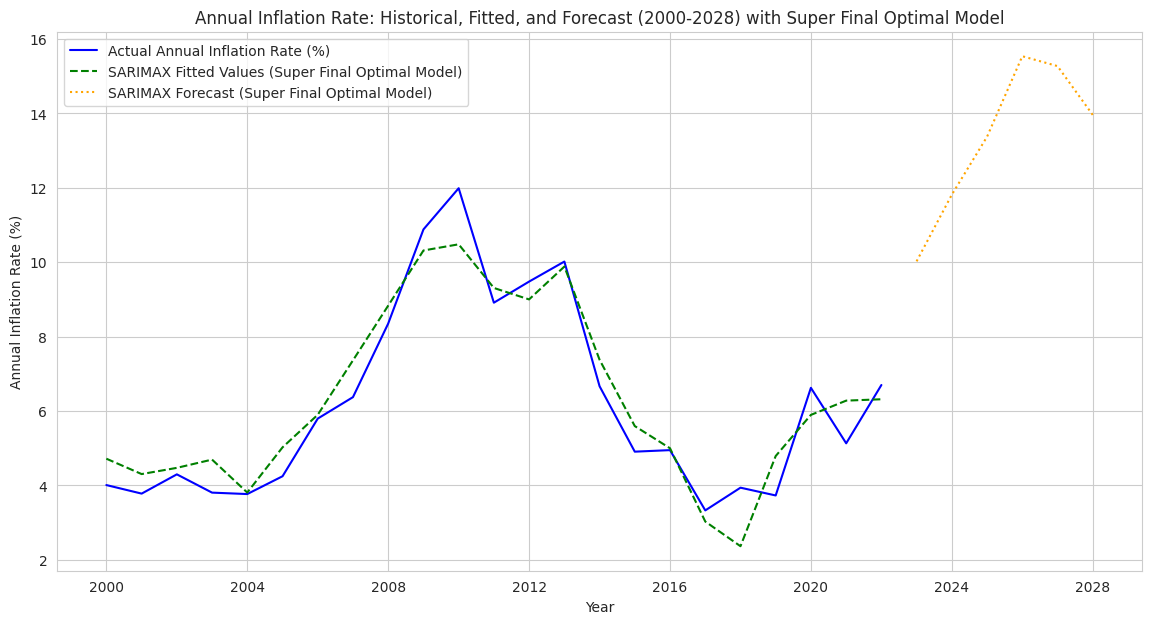

In [217]:
import matplotlib.pyplot as plt

# Filter future_exog_variables to include only the best combination of columns
future_exog_variables_final = future_exog_variables[['Petrol_Price', 'PNG_Price', 'CNG_Price']]

# Forecast inflation using the super final re-trained SARIMAX model
forecast_start_date = '2023-01-01'
forecast_end_date = '2028-01-01'

predictions = sarimax_results.predict(
    start=forecast_start_date,
    end=forecast_end_date,
    exog=future_exog_variables_final
)

print("Predicted Annual Inflation Rates (2023-2028) with super final optimal model:")
display(predictions)

# Plot the historical data, fitted values, and predictions
plt.figure(figsize=(14, 7))
plt.plot(inflation_series.index, inflation_series, label='Actual Annual Inflation Rate (%)', color='blue')
plt.plot(sarimax_results.fittedvalues.index, sarimax_results.fittedvalues, label='SARIMAX Fitted Values (Super Final Optimal Model)', color='green', linestyle='--')
plt.plot(predictions.index, predictions, label='SARIMAX Forecast (Super Final Optimal Model)', color='orange', linestyle=':')

plt.title('Annual Inflation Rate: Historical, Fitted, and Forecast (2000-2028) with Super Final Optimal Model')
plt.xlabel('Year')
plt.ylabel('Annual Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

### 19. Regenerate Interactive Widget with Super Final Optimal Model

### 20. Perform Ljung-Box Test on Refined Model Residuals

After re-training the SARIMAX model with the new optimal order `(4, 0, 3)` that achieved an RMSE of `0.75`, we will re-run the Ljung-Box test on the residuals of this refined model. This will confirm whether the increased model complexity has effectively removed the previously identified autocorrelations at lags 4 and 5.

In [219]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd # Ensure pandas is imported if not already

# Get the residuals from the final, super-optimized SARIMAX model
residuals_super_final = sarimax_results.resid

# Perform Ljung-Box test on the residuals
# We'll test up to 5 lags, as previously, which is reasonable for annual data points.
ljung_box_results_super_final = acorr_ljungbox(residuals_super_final, lags=[1, 2, 3, 4, 5])

print("Ljung-Box Test Results on Super Final SARIMAX Model Residuals:")
# For newer statsmodels versions, the output is a DataFrame
if isinstance(ljung_box_results_super_final, pd.DataFrame):
    display(ljung_box_results_super_final)
else:
    # Fallback for older tuple format if necessary
    print("Ljung-Box Statistic:", ljung_box_results_super_final[0])
    print("P-values:", ljung_box_results_super_final[1])

# Interpretation of results
print("\nInterpretation:")
print("A high p-value (typically > 0.05) for all lags suggests that the residuals are independently distributed (white noise),")
print("meaning there is no significant autocorrelation left in the residuals and the model is well-specified.")

Ljung-Box Test Results on Super Final SARIMAX Model Residuals:


,lb_stat,lb_pvalue
1,0.656728,0.417718
2,1.922871,0.382344
3,3.697337,0.296056
4,3.697360,0.448510
5,4.072821,0.538980



Interpretation:
A high p-value (typically > 0.05) for all lags suggests that the residuals are independently distributed (white noise),
meaning there is no significant autocorrelation left in the residuals and the model is well-specified.


In [218]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

def simulate_inflation_final(petrol, png, cng, forecast_year):
    clear_output(wait=True) # Clear previous output in the interactive cell

    # Create a DatetimeIndex for the single forecast year
    single_year_index = pd.to_datetime([f'{forecast_year}-01-01'])
    single_year_index.freq = 'YS'

    # Create the exogenous variables DataFrame for the single forecast year (only best combo)
    exog_for_prediction_final = pd.DataFrame(
        [[petrol, png, cng]],
        index=single_year_index,
        columns=['Petrol_Price', 'PNG_Price', 'CNG_Price']
    )

    # Make the prediction using the super final SARIMAX model
    prediction_result = sarimax_results.forecast(steps=1, exog=exog_for_prediction_final)

    print(f"Predicted Annual Inflation Rate for {forecast_year}: {prediction_result.iloc[0]:.2f}%")

# Create interactive widgets (FloatSlider for prices, IntSlider for year)
# Adjust min/max values based on the range of the actual fuel price data
petrol_slider_final = widgets.FloatSlider(
    value=fuel_price_df['Petrol_Price'].mean(), # Initial value
    min=fuel_price_df['Petrol_Price'].min(), max=fuel_price_df['Petrol_Price'].max() * 1.2, step=0.5,
    description='Petrol Price (Rs/Lit):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

png_slider_final = widgets.FloatSlider(
    value=fuel_price_df['PNG_Price'].mean(),
    min=fuel_price_df['PNG_Price'].min(), max=fuel_price_df['PNG_Price'].max() * 1.2, step=0.1,
    description='PNG Price (Rs/SCM):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

cng_slider_final = widgets.FloatSlider(
    value=fuel_price_df['CNG_Price'].mean(),
    min=fuel_price_df['CNG_Price'].min(), max=fuel_price_df['CNG_Price'].max() * 1.2, step=0.1,
    description='CNG Price (Rs/SCM):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

year_slider_final = widgets.IntSlider(
    value=2023,
    min=2023, max=2028, step=1,
    description='Forecast Year:',
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

# Use widgets.interactive to link the sliders to the simulation function
interactive_widget_final = widgets.interactive(
    simulate_inflation_final,
    petrol=petrol_slider_final,
    png=png_slider_final,
    cng=cng_slider_final,
    forecast_year=year_slider_final
)

display(interactive_widget_final)

interactive(children=(FloatSlider(value=76.61869565217391, description='Petrol Price (Rs/Lit):', max=155.676, …